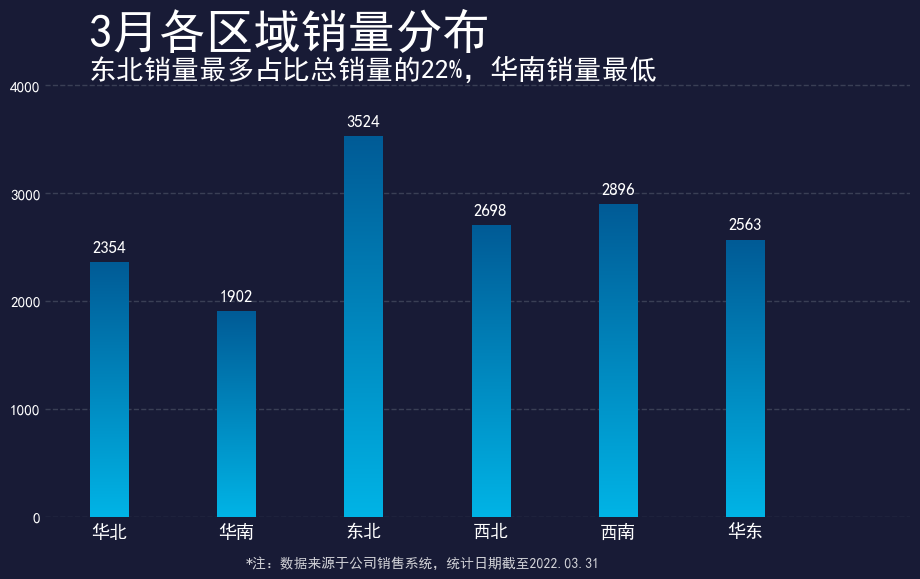

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
regions = ['华北', '华南', '东北', '西北', '西南', '华东']
sales = [2354, 1902, 3524, 2698, 2896, 2563]

# 颜色定义
bg_color = '#181B36'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字 (清晰锐利)
grid_color = '#3A3F55'      # 网格线颜色

# 渐变颜色定义 (RGB 0-1) - 顶部深蓝，底部亮蓝
color_top = np.array([0, 91, 150]) / 255.0   # 顶部深蓝
color_bot = np.array([0, 180, 230]) / 255.0  # 底部亮蓝

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 【核心修改】柱宽调细至 0.3，让所有柱子都像华北一样修长
bar_width = 0.3
x_positions = np.arange(len(regions)) + 0.5 

# 绘制渐变柱状图
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    rows = 256
    gradient_array = np.zeros((rows, 1, 3))
    for r in range(rows):
        ratio = r / (rows - 1)
        gradient_array[r, 0, :] = color_bot + (color_top - color_bot) * ratio
    
    left = x_pos - bar_width / 2
    right = x_pos + bar_width / 2
    
    # 使用 bilinear 平滑插值，消除锯齿，保证视觉宽度绝对一致
    ax.imshow(gradient_array, aspect='auto', extent=[left, right, 0, val],
              origin='lower', zorder=2, interpolation='bilinear')

# 在柱子上方添加数值标签 (纯白，加粗)
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    ax.text(
        x_pos, val + 80,
        str(val),
        ha='center', va='bottom',
        color=text_color,
        fontsize=12,
        fontweight='bold',
        zorder=3
    )

# 设置标题
ax.text(0.05, 1.12, '3月各区域销量分布',
        transform=ax.transAxes,
        fontsize=34, fontweight='bold', color=text_color,
        va='top', ha='left')

ax.text(0.05, 1.02, '东北销量最多占比总销量的22%，华南销量最低',
        transform=ax.transAxes,
        fontsize=20, fontweight='normal', color=text_color,
        va='top', ha='left')

# 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(regions, color=text_color, fontsize=13)
ax.tick_params(axis='x', length=0)

# 【核心修改】强制设置X轴范围，给左侧留出空间，防止华北柱子被挤压
ax.set_xlim(0, len(regions) + 0.8) 

ax.set_ylim(0, 4200)
ax.set_yticks([0, 1000, 2000, 3000, 4000])
ax.set_yticklabels(['0', '1000', '2000', '3000', '4000'], color=text_color, fontsize=11)
ax.tick_params(axis='y', length=0)

# 设置网格线
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 添加底部注释
fig.text(
    0.32, 0.06,
    '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
    color=text_color,
    fontsize=10,
    alpha=0.8
)

# 调整布局
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.subplots_adjust(left=0.12)

plt.show()


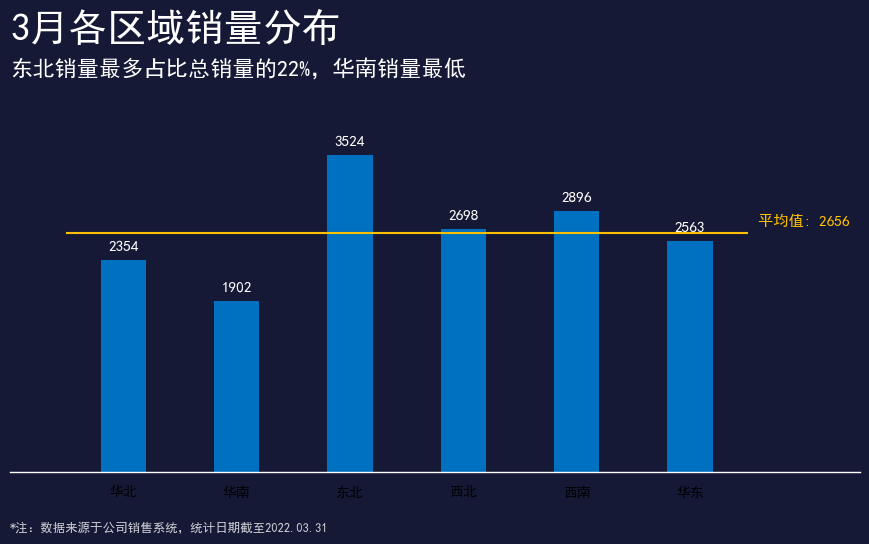

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
regions = ['华北', '华南', '东北', '西北', '西南', '华东']
sales = [2354, 1902, 3524, 2698, 2896, 2563]
avg_sales = 2656

# 颜色定义 (完全匹配图1)
bg_color = '#161936'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字
line_color = '#FFC000'      # 平均值线 (橙黄色)
bar_color = '#0070C0'       # 柱子主色 (图1看起来接近纯色，这里用标准蓝)

# 1. 创建画布 (不使用 subplots，手动控制布局以防重叠)
fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor(bg_color)

# 2. 放置标题 (在 Figure 坐标系中，y=0.9 附近，绝对在图表上方)
fig.text(0.1, 0.92, '3月各区域销量分布', 
         color=text_color, fontsize=28, fontweight='bold', va='top')
fig.text(0.1, 0.84, '东北销量最多占比总销量的22%，华南销量最低', 
         color=text_color, fontsize=16, va='top')

# 3. 创建图表区域 (手动指定位置：[左, 下, 宽, 高])
# 这样图表区域就在标题下方，绝对不会重叠
ax = fig.add_axes([0.1, 0.15, 0.85, 0.6]) 
ax.set_facecolor(bg_color)

# 4. 绘制柱子
x_positions = np.arange(len(regions)) + 1  # 1, 2, 3, 4, 5, 6
bar_width = 0.4

# 为了完全像图1，这里使用纯色，如果需要之前的轻微渐变可取消注释渐变代码
# 图1看起来非常像纯色 #0070C0
for x_pos, val in zip(x_positions, sales):
    # 绘制柱子 (使用 bar 函数，宽度固定，保证一模一样粗)
    ax.bar(x_pos, val, width=bar_width, color=bar_color, zorder=2, edgecolor='none')

# 5. 绘制平均值线
# 线从 x=0.5 到 x=6.5 (覆盖所有柱子)
ax.plot([0.5, 6.5], [avg_sales, avg_sales], color=line_color, linewidth=1.5, zorder=3)

# 6. 添加平均值文字标签 (在线的右侧上方)
ax.text(6.6, avg_sales + 50, f'平均值: {avg_sales}', 
        color=line_color, fontsize=11, fontweight='bold',
        va='bottom', ha='left', zorder=3)

# 7. 添加柱子数值标签
for x_pos, val in zip(x_positions, sales):
    ax.text(
        x_pos, val + 80,  # 在柱子顶部上方 80 单位
        str(val),
        ha='center', va='bottom',
        color=text_color,
        fontsize=11,
        zorder=3
    )

# 8. 设置坐标轴 (极简风格，匹配图1)
ax.set_xticks(x_positions)
ax.set_xticklabels(regions, color=text_color, fontsize=12) # 强制白色
ax.tick_params(axis='x', length=0, pad=10) # 标签下移

# 隐藏 Y 轴
ax.yaxis.set_visible(False)

# 设置 X 轴底线 (白色)
ax.spines['bottom'].set_color('white')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('outward', 0))

# 隐藏其他边框
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置范围，给右侧文字留空间
ax.set_xlim(0, 7.5)
ax.set_ylim(0, 4000) # 留出空间给最高的标签 3524

# 9. 添加底部注释
fig.text(0.1, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
         color=text_color, fontsize=9, alpha=0.8)

plt.show()

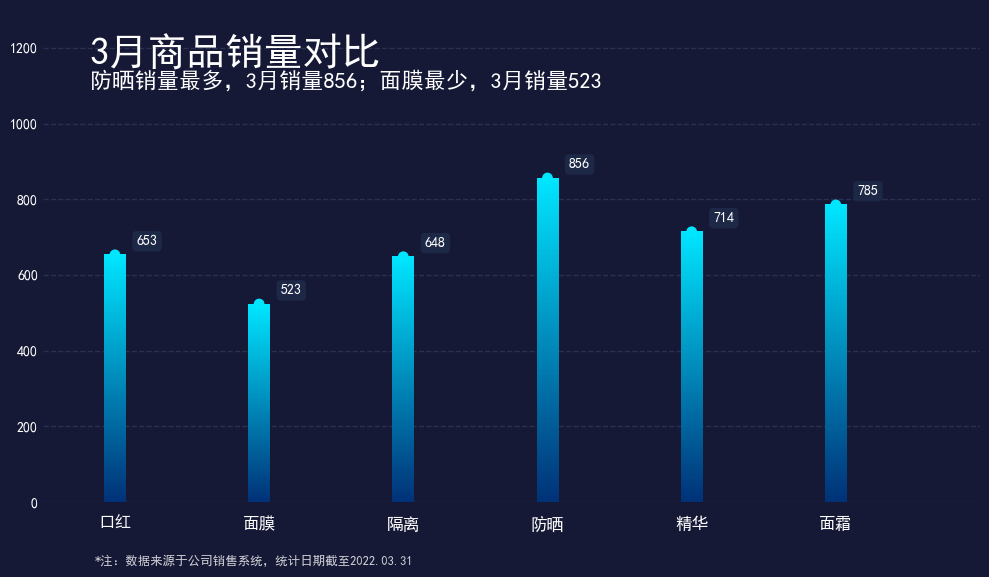

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
products = ['口红', '面膜', '隔离', '防晒', '精华', '面霜']
sales = [653, 523, 648, 856, 714, 785]

# 颜色定义
bg_color = '#161936'        # 深蓝背景
text_color = '#FFFFFF'      # 纯白色文字
grid_color = '#2A3050'      # 网格线颜色 (暗灰色虚线)

# 渐变颜色定义 (RGB 0-1) - 底部深蓝，顶部亮青
color_top = np.array([0, 230, 255]) / 255.0   # 顶部亮青 #00E6FF
color_bot = np.array([0, 50, 120]) / 255.0   # 底部深蓝 #003278

# 创建画布
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 柱子设置 (非常细)
bar_width = 0.15
x_positions = np.arange(len(products)) + 1 

# 1. 绘制渐变柱状图 (细长型)
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    rows = 256
    gradient_array = np.zeros((rows, 1, 3))
    for r in range(rows):
        ratio = r / (rows - 1)
        gradient_array[r, 0, :] = color_bot + (color_top - color_bot) * ratio
    
    left = x_pos - bar_width / 2
    right = x_pos + bar_width / 2
    
    # 使用 nearest 插值，保证边缘锐利
    ax.imshow(gradient_array, aspect='auto', extent=[left, right, 0, val],
              origin='lower', zorder=2, interpolation='nearest')

# 2. 绘制顶部的圆点 (Marker)
# 颜色使用顶部亮青色
ax.scatter(x_positions, sales, color=color_top, s=60, zorder=3, edgecolors='none')

# 3. 添加带背景框的数值标签
for i, (x_pos, val) in enumerate(zip(x_positions, sales)):
    # 标签位置在圆点右上方
    ax.text(
        x_pos + 0.15, val + 20,  # 稍微偏右
        str(val),
        ha='left', va='bottom',
        color=text_color,
        fontsize=10,
        zorder=4,
        # 背景框样式：深蓝底色，圆角
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1E2A4A', edgecolor='none', alpha=0.9)
    )

# 4. 设置标题
ax.text(0.05, 0.95, '3月商品销量对比',
        transform=ax.transAxes,
        fontsize=28, fontweight='bold', color=text_color,
        va='top', ha='left')

ax.text(0.05, 0.88, '防晒销量最多，3月销量856；面膜最少，3月销量523',
        transform=ax.transAxes,
        fontsize=16, fontweight='normal', color=text_color,
        va='top', ha='left')

# 5. 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(products, color=text_color, fontsize=12)
ax.tick_params(axis='x', length=0, pad=10)

ax.set_ylim(0, 1300)
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200])
ax.set_yticklabels(['0', '200', '400', '600', '800', '1000', '1200'], color=text_color, fontsize=10)
ax.tick_params(axis='y', length=0)

# 6. 设置网格线 (水平虚线)
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

# 设置X轴范围，给右侧标签留空间
ax.set_xlim(0.5, 7.0)

# 7. 添加底部注释
fig.text(
    0.1, 0.05,
    '*注：数据来源于公司销售系统，统计日期截至2022.03.31',
    color=text_color,
    fontsize=9,
    alpha=0.8
)

# 调整布局
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.show()

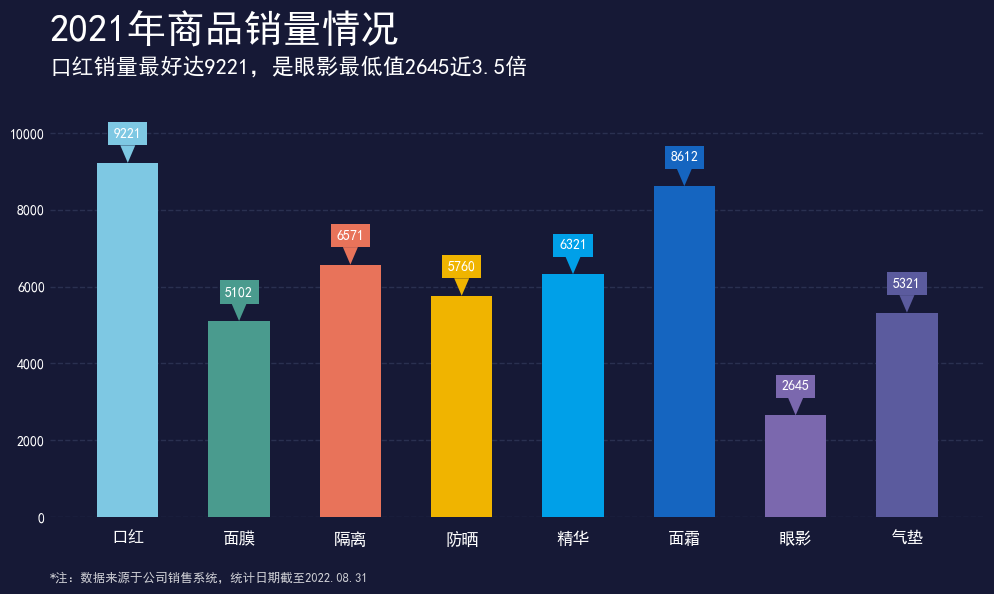

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
matplotlib.rcParams['axes.unicode_minus'] = False

# 数据
products = ['口红', '面膜', '隔离', '防晒', '精华', '面霜', '眼影', '气垫']
sales = [9221, 5102, 6571, 5760, 6321, 8612, 2645, 5321]

# 每根柱子的颜色
bar_colors = [
    '#7EC8E3',  # 口红 - 浅天蓝
    '#4A9B8E',  # 面膜 - 青绿色
    '#E8735A',  # 隔离 - 珊瑚橙
    '#F0B400',  # 防晒 - 金黄色
    '#00A0E8',  # 精华 - 亮蓝色
    '#1565C0',  # 面霜 - 深蓝色
    '#7B68AE',  # 眼影 - 蓝紫色
    '#5B5B9E',  # 气垫 - 深靛蓝
]

# 颜色定义
bg_color = '#161936'
text_color = '#FFFFFF'
grid_color = '#2A3050'

# 1. 创建画布 (手动控制布局)
fig = plt.figure(figsize=(11, 6.5))
fig.patch.set_facecolor(bg_color)

# 2. 放置标题 (在 Figure 坐标系中，y=0.92 附近，绝对在图表上方)
fig.text(0.1, 0.93, '2021年商品销量情况', 
         color=text_color, fontsize=28, fontweight='bold', va='top')
fig.text(0.1, 0.86, '口红销量最好达9221，是眼影最低值2645近3.5倍', 
         color=text_color, fontsize=16, va='top')

# 3. 创建图表区域 (在标题下方)
ax = fig.add_axes([0.1, 0.15, 0.85, 0.65]) 
ax.set_facecolor(bg_color)

# 柱子设置
bar_width = 0.55
x_positions = np.arange(len(products)) + 1 

# 4. 绘制彩色柱状图
for i, (x_pos, val, color) in enumerate(zip(x_positions, sales, bar_colors)):
    ax.bar(x_pos, val, width=bar_width, color=color, zorder=2, edgecolor='none')

# 5. 添加带小三角尾巴的标签框 (标签位置再往上抬，避免拥挤)
for i, (x_pos, val, color) in enumerate(zip(x_positions, sales, bar_colors)):
    ax.annotate(
        str(val),
        xy=(x_pos, val),              # 箭头尖端指向柱子顶部
        xytext=(x_pos, val + 600),    # 【修改】标签框位置从 +500 改为 +600，更靠上
        ha='center', va='bottom',
        color='white',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='square,pad=0.4', facecolor=color, edgecolor='none'),
        arrowprops=dict(
            arrowstyle='wedge,tail_width=0.6',
            facecolor=color,
            edgecolor='none',
            mutation_scale=18,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=4
    )

# 6. 设置坐标轴
ax.set_xticks(x_positions)
ax.set_xticklabels(products, color=text_color, fontsize=12)
ax.tick_params(axis='x', length=0, pad=10)

ax.set_ylim(0, 11000)
ax.set_yticks([0, 2000, 4000, 6000, 8000, 10000])
ax.set_yticklabels(['0', '2000', '4000', '6000', '8000', '10000'], color=text_color, fontsize=10)
ax.tick_params(axis='y', length=0)

# 7. 设置网格线
ax.yaxis.grid(True, linestyle='--', color=grid_color, linewidth=1, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# 隐藏边框
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlim(0.3, 8.7)

# 8. 添加底部注释
fig.text(
    0.1, 0.05,
    '*注：数据来源于公司销售系统，统计日期截至2022.08.31',
    color=text_color,
    fontsize=9,
    alpha=0.8
)

plt.show()

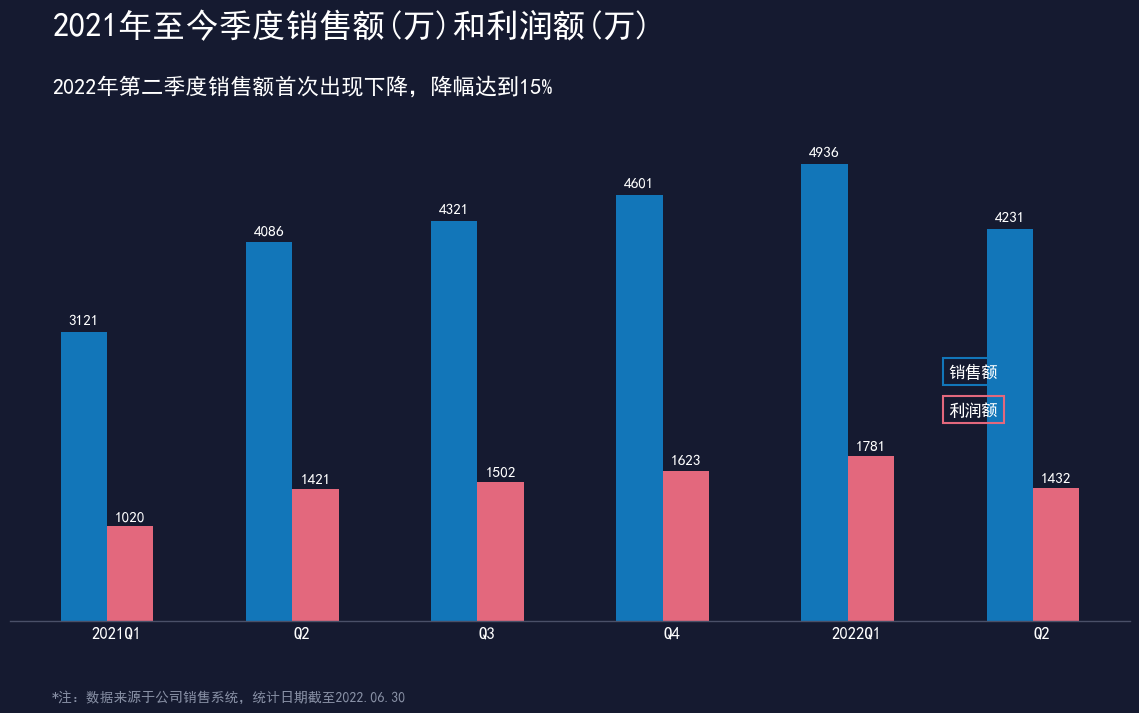

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体 (根据你的系统选择，Windows通常用SimHei或Microsoft YaHei，Mac用Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 2. 数据准备
labels = ['2021Q1', 'Q2', 'Q3', 'Q4', '2022Q1', 'Q2']
sales = [3121, 4086, 4321, 4601, 4936, 4231]
profit = [1020, 1421, 1502, 1623, 1781, 1432]

x = np.arange(len(labels))
width = 0.25  # 柱子宽度

# 3. 创建画布
fig, ax = plt.subplots(figsize=(14, 8))
bg_color = '#151a30'  # 深蓝色背景
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制柱状图
# 稍微调整 x 坐标让分组更紧凑
rects1 = ax.bar(x - width/2 - 0.05, sales, width, label='Sales', color='#1276b9', zorder=2)
rects2 = ax.bar(x + width/2 - 0.05, profit, width, label='Profit', color='#e3687d', zorder=2)

# 5. 添加柱子顶部的数值标签
def add_labels(rects, offset_y=50):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., height + offset_y,
                f'{int(height)}',
                ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

add_labels(rects1, offset_y=60)
add_labels(rects2, offset_y=40) # 利润额柱子较矮，标签稍微低一点以免太突兀，或者保持一致

# 6. 设置 X 轴
ax.set_xticks(x)
ax.set_xticklabels(labels, color='white', fontsize=12)
ax.tick_params(axis='x', length=0) # 去掉X轴刻度线

# 7. 隐藏 Y 轴和边框
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# 设置底部边框为灰色细线
ax.spines['bottom'].set_color('#4a5068')
ax.spines['bottom'].set_linewidth(1)

# 8. 添加标题和副标题 (使用 fig.text 精确定位)
fig.text(0.13, 0.88, '2021年至今季度销售额(万)和利润额(万)', 
         color='white', fontsize=24, fontweight='bold', family='sans-serif')
fig.text(0.13, 0.81, '2022年第二季度销售额首次出现下降，降幅达到15%', 
         color='white', fontsize=16, family='sans-serif')

# 9. 添加自定义图例 (模拟原图的带框文字)
# 销售额图例
ax.text(0.86, 0.52, '销售额', transform=ax.transAxes,
        color='white', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='#1276b9', linewidth=1.5),
        ha='center', va='center')
# 利润额图例
ax.text(0.86, 0.44, '利润额', transform=ax.transAxes,
        color='white', fontsize=12,
        bbox=dict(facecolor='none', edgecolor='#e3687d', linewidth=1.5),
        ha='center', va='center')

# 10. 添加底部注释
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', 
         color='#8890a5', fontsize=10)

# 11. 调整布局
plt.subplots_adjust(left=0.1, right=0.9, top=0.75, bottom=0.15)

# 显示图表
plt.show()

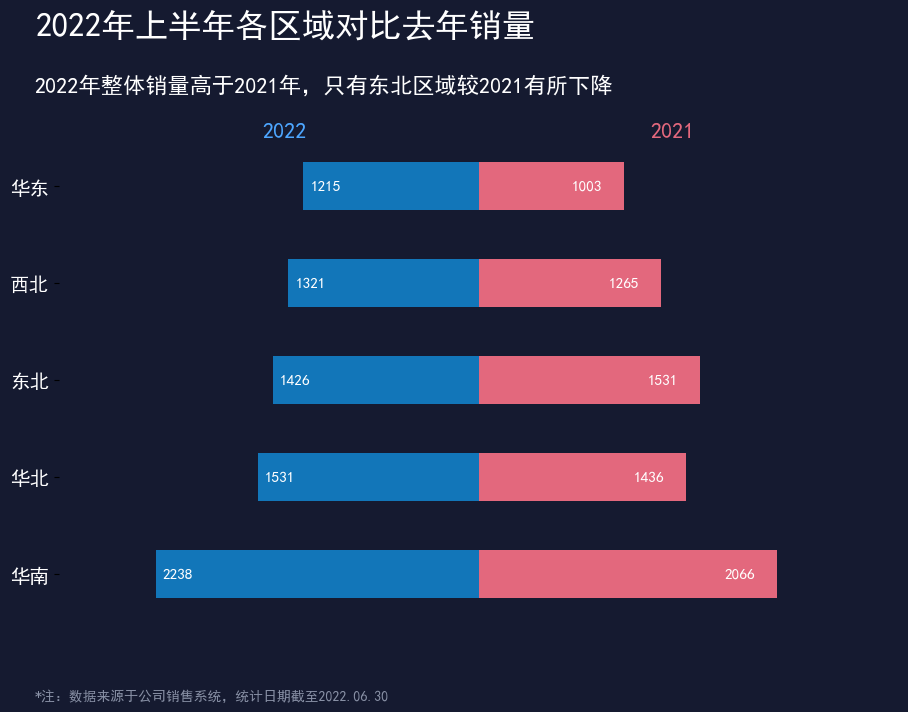

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 2. 数据准备 (按图表从上到下的顺序，即2022年销量降序)
regions = ['华南', '华北', '东北', '西北', '华东']
sales_2022 = [2238, 1531, 1426, 1321, 1215]
sales_2021 = [2066, 1436, 1531, 1265, 1003]

y = np.arange(len(regions))

# 3. 创建画布
fig, ax = plt.subplots(figsize=(12, 8))
bg_color = '#151a30'
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制条形图
# 左侧 (2022年): 使用负值使其向左延伸
# 颜色: 蓝色 #1276b9
bar_left = ax.barh(y, [-x for x in sales_2022], height=0.5, color='#1276b9', zorder=2)

# 右侧 (2021年): 使用正值使其向右延伸
# 颜色: 粉色 #e3687d
bar_right = ax.barh(y, sales_2021, height=0.5, color='#e3687d', zorder=2)

# 5. 添加条形图内部的数值标签
# 左侧标签 (2022)
for i, val in enumerate(sales_2022):
    # x位置：负值 + 一点偏移量，使其在条形图内部左侧
    # 原图数字在条形图左侧内部
    ax.text(-val + 50, i, str(val), ha='left', va='center', color='white', fontsize=11)

# 右侧标签 (2021)
for i, val in enumerate(sales_2021):
    # x位置：正值 - 一点偏移量，使其在条形图内部右侧
    ax.text(val - 150, i, str(val), ha='right', va='center', color='white', fontsize=11) # 偏移量大一点防止溢出

# 6. 设置 Y 轴 (中间的区域名)
ax.set_yticks(y)
ax.set_yticklabels(regions, color='white', fontsize=14, fontweight='bold')
# 调整Y轴标签位置到中间 (x=0附近)
ax.yaxis.set_label_coords(-0.05, 0.5) # 微调

# 7. 隐藏 X 轴和边框
ax.set_xticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# 8. 添加顶部的 "2022" 和 "2021" 标题
# 需要根据数据最大值动态计算位置，或者手动指定
max_val = max(max(sales_2022), max(sales_2021))
ax.text(-max_val * 0.6, len(regions) - 0.5, '2022', color='#4da6ff', fontsize=16, ha='center', fontweight='bold') # 淡蓝色
ax.text(max_val * 0.6, len(regions) - 0.5, '2021', color='#e3687d', fontsize=16, ha='center', fontweight='bold') # 淡粉色/红色

# 9. 添加主标题和副标题 (使用 fig.text)
fig.text(0.13, 0.88, '2022年上半年各区域对比去年销量', 
         color='white', fontsize=24, fontweight='bold')
fig.text(0.13, 0.81, '2022年整体销量高于2021年，只有东北区域较2021有所下降', 
         color='white', fontsize=16)

# 10. 添加底部注释
fig.text(0.13, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.06.30', 
         color='#8890a5', fontsize=10)

# 11. 调整 X 轴范围，留出中间空隙放文字
# 左边留够空间放2022的条，右边留够空间放2021的条，中间留空
ax.set_xlim(-max_val * 1.3, max_val * 1.3)

# 12. 调整布局
plt.subplots_adjust(left=0.15, right=0.85, top=0.75, bottom=0.15)

plt.show()

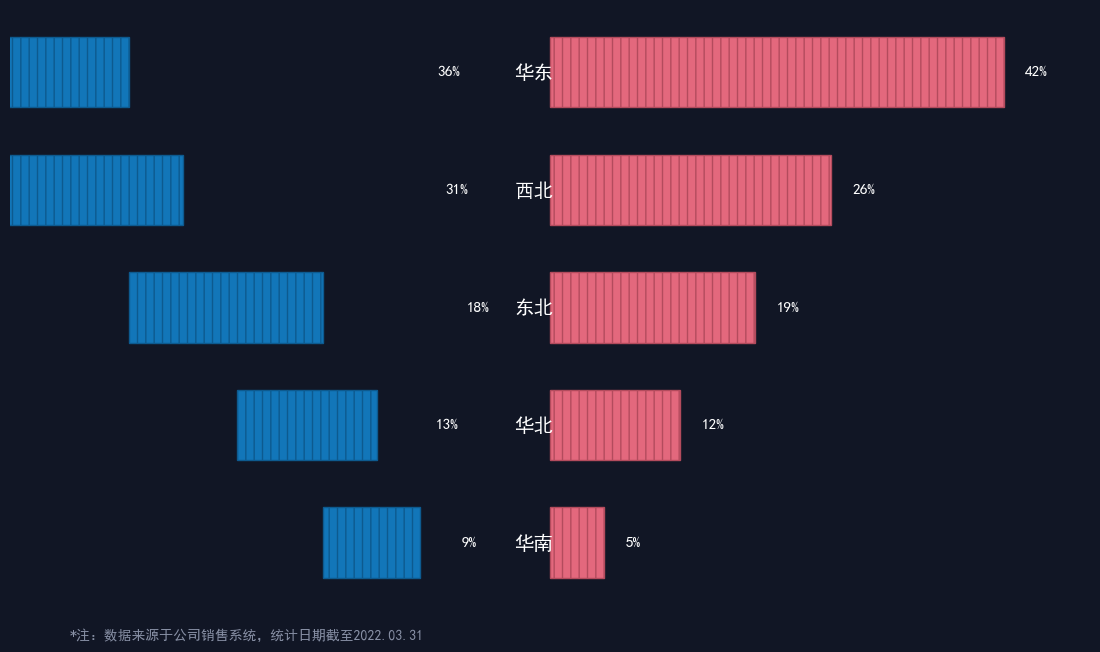

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['hatch.linewidth'] = 1.0 

# 2. 数据准备 (注意：这次是从上到下从小到大排列：华南 -> 华东)
regions = ['华南', '华北', '东北', '西北', '华东']
sales_2022 = [9, 13, 18, 31, 36]   # 左侧蓝色
sales_2021 = [5, 12, 19, 26, 42]   # 右侧粉色

y = np.arange(len(regions))

# 3. 创建画布
fig, ax = plt.subplots(figsize=(12, 7))
bg_color = '#111625' # 更深的背景色，接近图4
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 4. 绘制条形图
# 核心对齐逻辑：
# 左侧条形：所有条形的【右边缘】对齐在 x = -1 (靠近中间轴)
# 右侧条形：所有条形的【左边缘】对齐在 x = 1 (靠近中间轴)

gap = 1.5  # 中间留空的距离
height = 0.6

# 左侧 (2022) - 蓝色
# width为负值，left计算使得 right_edge = left + width = -gap
# left = -gap - width = -gap - (-val) = -gap + val ?? 不对
# 我们要画从 (-gap - val) 到 (-gap)。
# width = -val. left = -gap - val.
bar_left = ax.barh(y, [-x for x in sales_2022], height=height, 
                   left=[-gap - x for x in sales_2022], 
                   color='#1276b9', edgecolor='#0d5a8f', hatch='||', zorder=2)

# 右侧 (2021) - 粉色
# 我们要画从 (gap) 到 (gap + val)。
# width = val. left = gap.
bar_right = ax.barh(y, sales_2021, height=height, 
                    left=[gap] * len(sales_2021), 
                    color='#e3687d', edgecolor='#b34b5d', hatch='||', zorder=2)

# 5. 添加标签
# 左侧标签 (在条形内部，靠右侧/靠中间)
for i, val in enumerate(sales_2022):
    # 位置：右边缘(-gap) 往左一点点
    x_pos = -gap - (val * 0.15) - 1 
    # 如果条形太短(如9%)，数字可能放不下，稍微调整
    if val < 15:
        x_pos = -gap - val/2 # 放中间
    ax.text(x_pos, i, f'{val}%', ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# 右侧标签 (在条形外部右侧)
for i, val in enumerate(sales_2021):
    x_pos = gap + val + 2
    ax.text(x_pos, i, f'{val}%', ha='left', va='center', color='white', fontsize=11)

# 6. 中间的区域名称
# 清空默认Y轴
ax.set_yticks([])
# 手动在中间 x=0 处画文字
for i, region in enumerate(regions):
    ax.text(0, i, region, ha='center', va='center', color='white', fontsize=14, fontweight='bold')

# 7. 隐藏坐标轴和边框
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# 8. 设置X轴范围
max_val = max(max(sales_2022), max(sales_2021))
ax.set_xlim(-gap - max_val - 5, gap + max_val + 8)

# 9. 添加底部注释 (图4没有大标题，只有底部注释)
fig.text(0.1, 0.05, '*注：数据来源于公司销售系统，统计日期截至2022.03.31', 
         color='#8890a5', fontsize=10)

# 10. 调整布局
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.1)

plt.show()